In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv('/content/cleaned_breast_cancer_dataset.csv')
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [4]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDiagnosis Distribution:")
print(df['diagnosis'].value_counts())

Dataset Shape: (569, 31)

Columns:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'diagnosis']

Missing Values:
0

Diagnosis Distribution:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64


In [5]:
df['diagnosis'] = df['diagnosis'].map({
    'benign': 0,
    'malignant': 1
})

df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


In [6]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [7]:
X = X.replace([np.inf, -np.inf], np.nan)

print("Missing values:", X.isnull().sum().sum())

Missing values: 0


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [13]:
y_pred_lr = logistic_model.predict(X_test_scaled)

In [14]:
print("Logistic Regression")
print("-------------------")

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

Logistic Regression
-------------------
Accuracy: 0.9649122807017544
Precision: 0.975
Recall: 0.9285714285714286
F1 Score: 0.9512195121951219


In [15]:
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=['Benign', 'Malignant']
))

              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [16]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [17]:
y_pred_rf = random_forest.predict(X_test)

In [18]:
print("Random Forest")
print("-------------")

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

Random Forest
-------------
Accuracy: 0.9736842105263158
Precision: 1.0
Recall: 0.9285714285714286
F1 Score: 0.9629629629629629


In [19]:
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Benign', 'Malignant']
))

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [21]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [22]:
y_pred_dt = decision_tree.predict(X_test)

In [23]:
print("Decision Tree")
print("-------------")

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("Precision:",
      precision_score(y_test, y_pred_dt))

print("Recall:",
      recall_score(y_test, y_pred_dt))

print("F1 Score:",
      f1_score(y_test, y_pred_dt))

Decision Tree
-------------
Accuracy: 0.9122807017543859
Precision: 0.9705882352941176
Recall: 0.7857142857142857
F1 Score: 0.868421052631579


In [24]:
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=['Benign', 'Malignant']
))

              precision    recall  f1-score   support

      Benign       0.89      0.99      0.93        72
   Malignant       0.97      0.79      0.87        42

    accuracy                           0.91       114
   macro avg       0.93      0.89      0.90       114
weighted avg       0.92      0.91      0.91       114



In [25]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220
1,Decision Tree,0.912281,0.970588,0.785714,0.868421
2,Random Forest,0.973684,1.000000,0.928571,0.962963


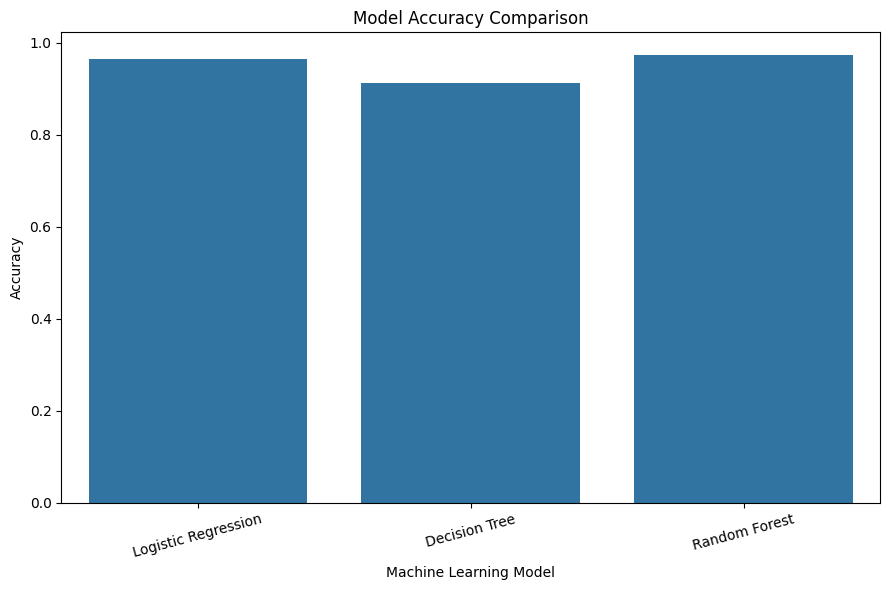

In [27]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)

plt.tight_layout()

plt.show()

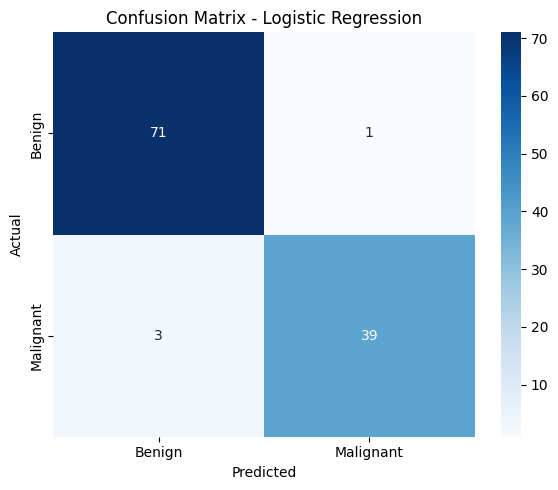

In [29]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()

plt.show()

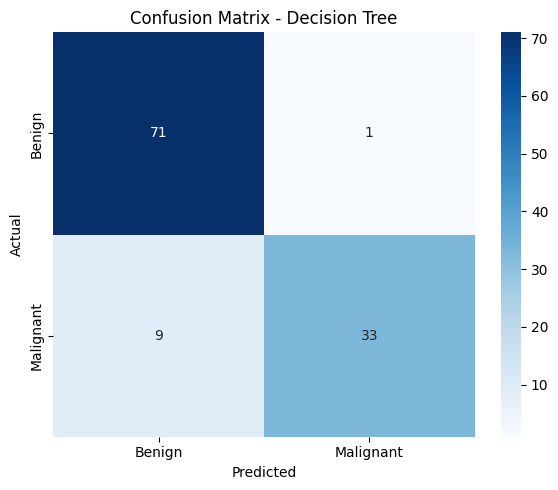

In [30]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)

plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()

plt.show()

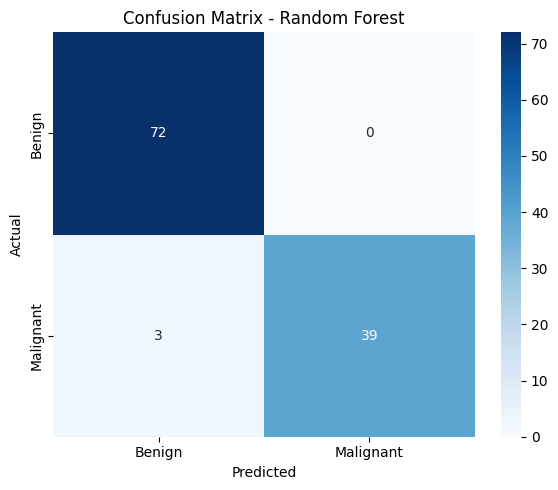

In [31]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign', 'Malignant'],
    yticklabels=['Benign', 'Malignant']
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()

plt.show()

In [32]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
23,worst area,0.151734
27,worst concave points,0.127215
20,worst radius,0.095235
2,mean perimeter,0.085316
22,worst perimeter,0.084327
7,mean concave points,0.078028
0,mean radius,0.061439
6,mean concavity,0.057463
3,mean area,0.033702
26,worst concavity,0.030279


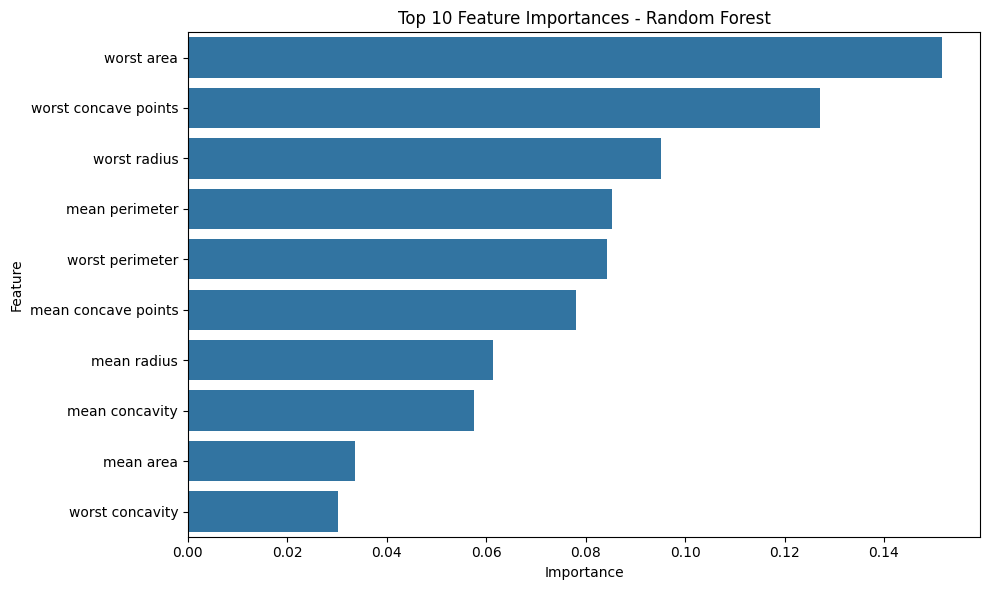

In [34]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.tight_layout()

plt.show()

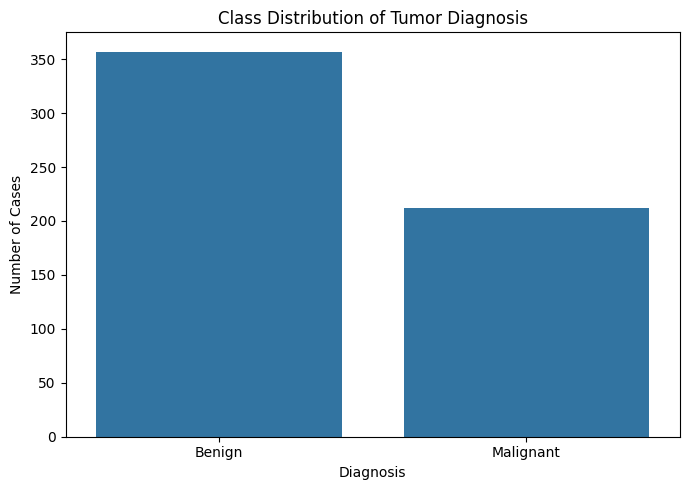

In [35]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='diagnosis'
)

plt.title('Class Distribution of Tumor Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Cases')

plt.xticks(
    [0, 1],
    ['Benign', 'Malignant']
)

plt.tight_layout()


plt.show()